In [1]:
from Montreal_UHI_toolbox import *

In [2]:
from sklearn.linear_model import LinearRegression

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [3]:
path = '/runoff/gulley/St_Laurent/intermediates/station' # move tasmin to /runoff/gulley/St_Laurent/intermediates/station
avgs = {}
stds = {}
for field in ['tasmax','tas','tasmin']:
    avgs[field] = xr.open_zarr(f'{path}/seasons_avg_{field}.zarr')[field].drop_vars(['urban_fraction','lake_fraction'])
    stds[field] = xr.open_zarr(f'{path}/seasons_std_{field}.zarr')[field].drop_vars(['urban_fraction','lake_fraction'])
    

In [4]:
# Add (blurred) TEB fields
for static_field in TEB_geophys: 
    static_field = static_field.rename(f'{static_field.name}_TEB')
    if 'lev' in static_field.coords:
        static_field = static_field.sel(lev=1) # All levels are identical in the TEB fields so I'll just take the first
        static_field = static_field.rename(f'{static_field.name}_lev1_TEB')
    for field in ['tasmax','tas','tasmin']: # Could just setcoords
        avgs[field] = add_blurred_field_to_stations(static_field,sigma=1.5,stations=avgs[field])
        stds[field] = add_blurred_field_to_stations(static_field,stations=stds[field])
        
        # Option to include raw field as a coordinate
        # avgs[field] = add_field_to_stations(static_field,sigma=1.5,stations=avgs[field])
        

In [5]:
# Add (blurred) CLASS fields 
for lev in veg_levs:
    static_field = veg_fields.sel(lev=lev).rename(veg_levs[lev])
    for field in ['tasmax','tas','tasmin']:
        avgs[field] = add_blurred_field_to_stations(static_field,sigma=1.5,stations=avgs[field])
        stds[field] = add_blurred_field_to_stations(static_field,sigma=1.5,stations=stds[field])

        # Option to include raw field as a coordinate
        # avgs[field] = add_field_to_stations(static_field,stations=avgs[field])

In [6]:
# Forgot to include elevation as a coordinate, and this may be pertinent in the regression
for field in ['tasmax','tas','tasmin']:
    avgs[field] = avgs[field].assign_coords({'elev': stations.elev})
    stds[field] = stds[field].assign_coords({'elev': stations.elev})

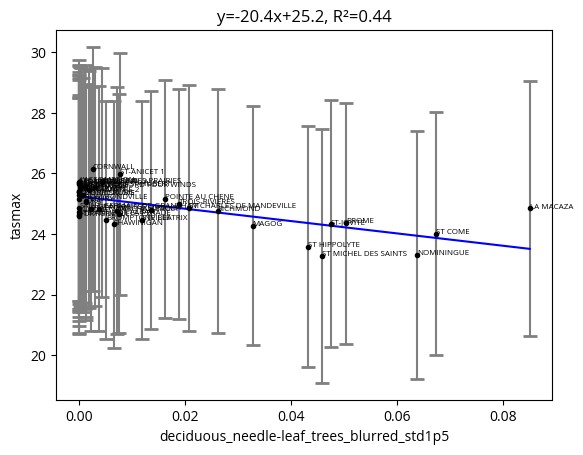

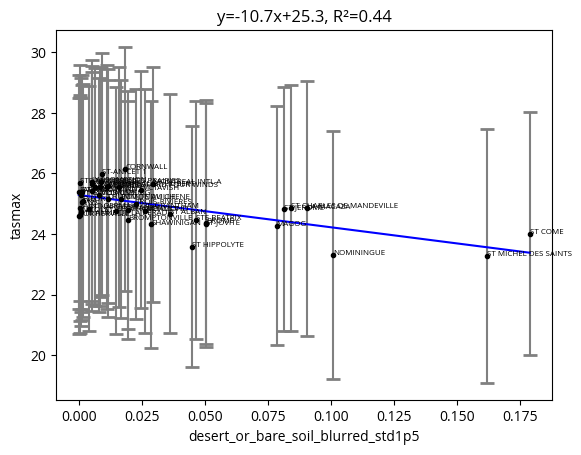

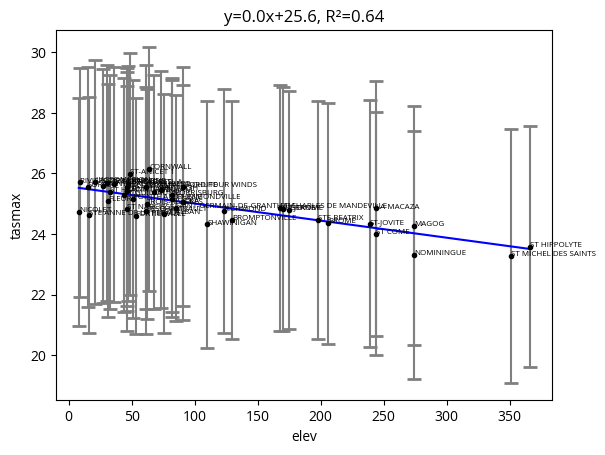

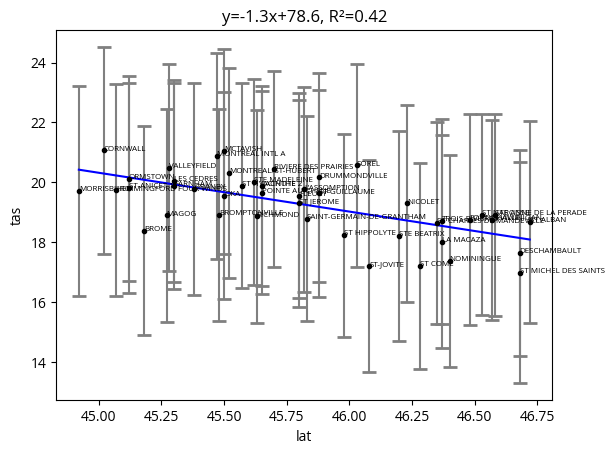

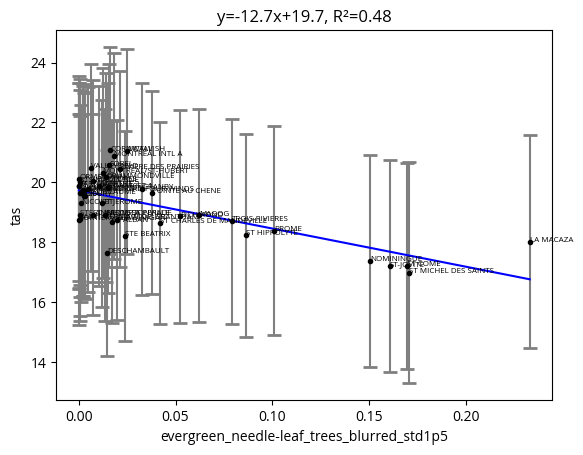

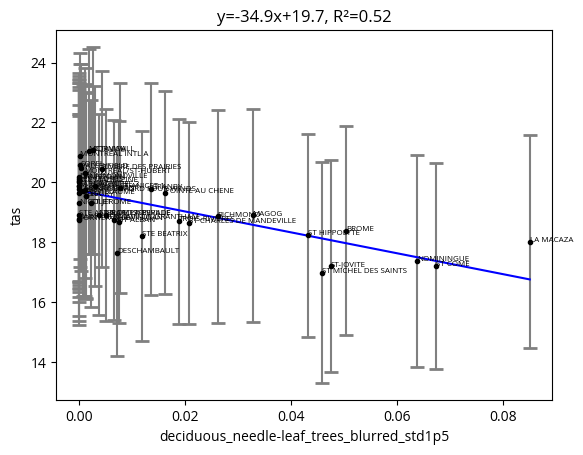

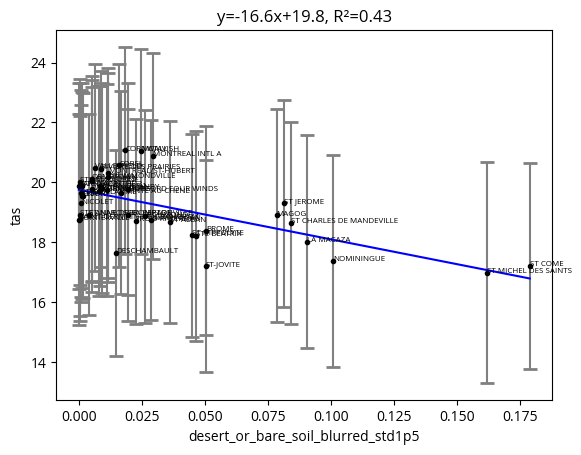

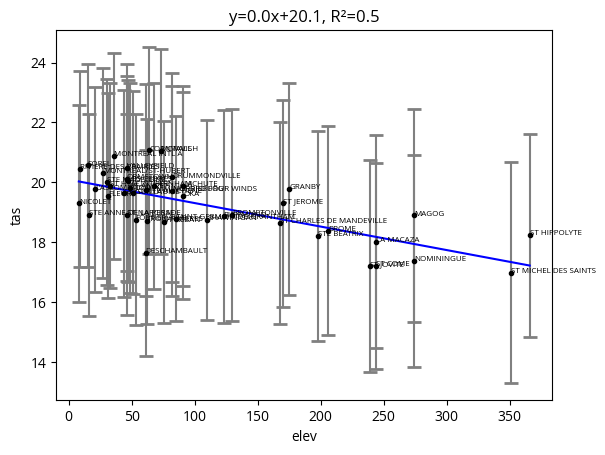

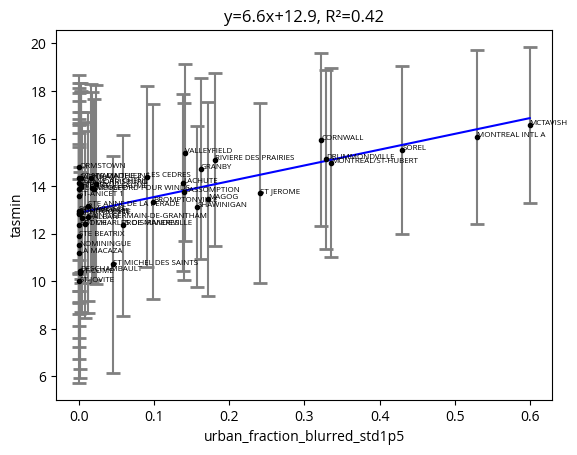

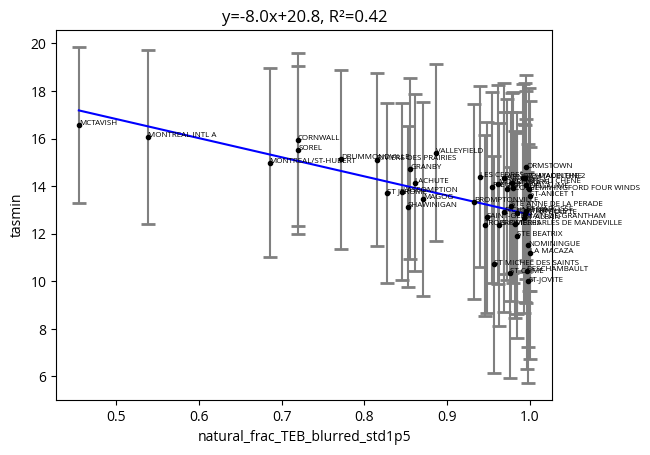

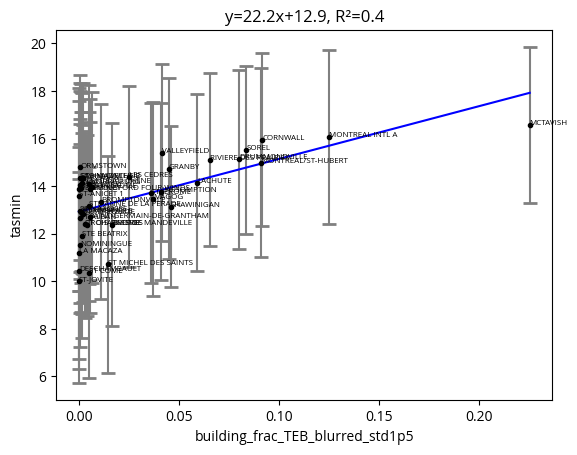

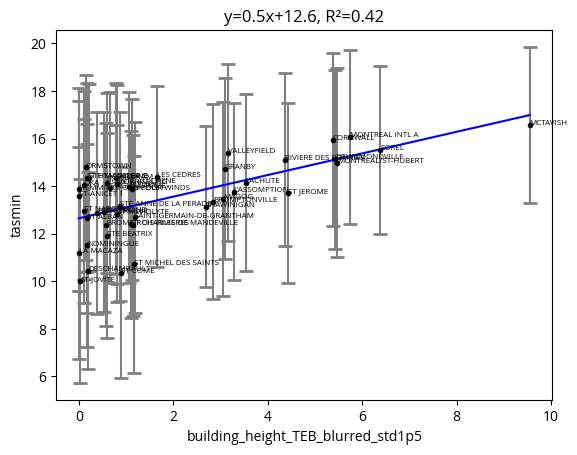

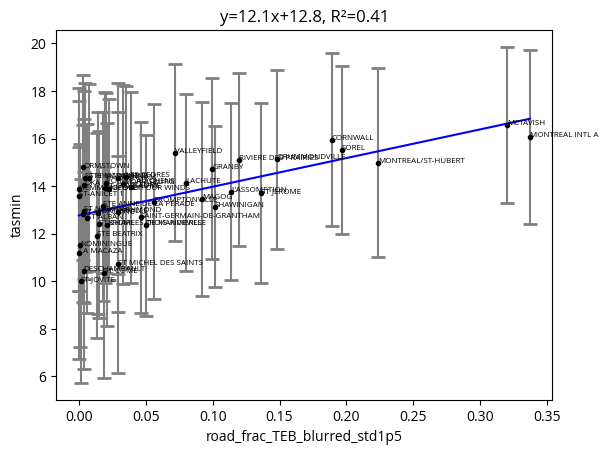

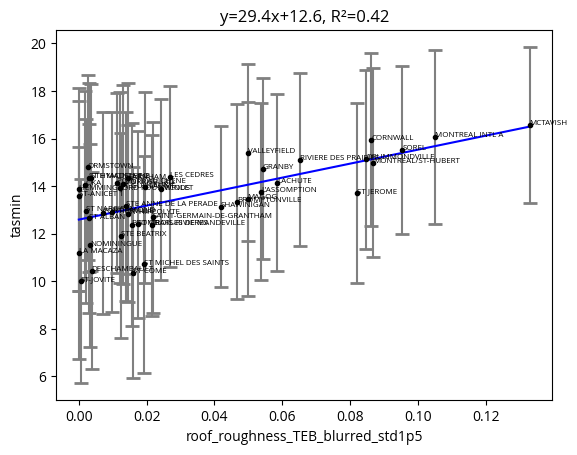

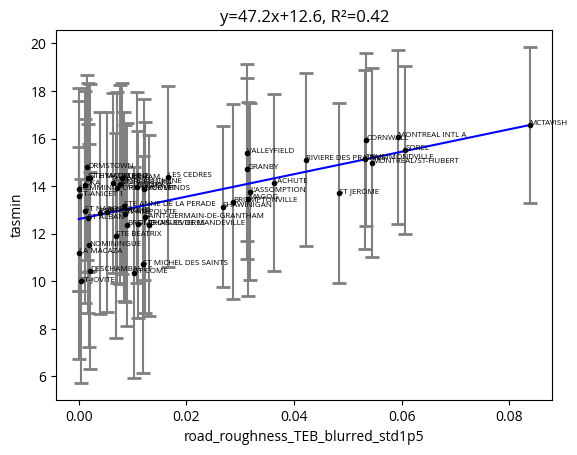

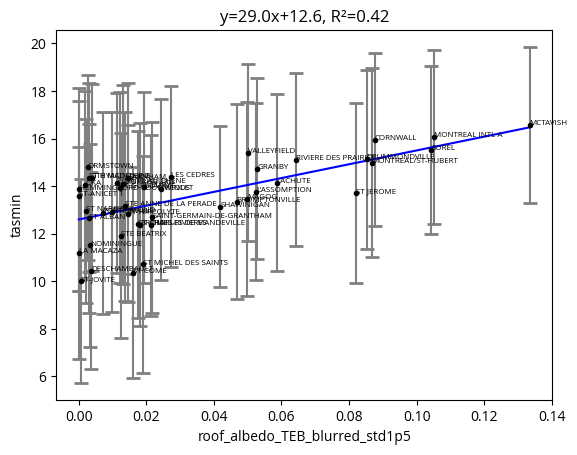

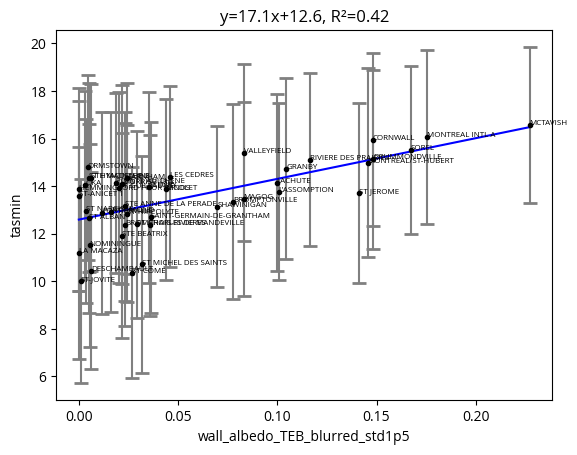

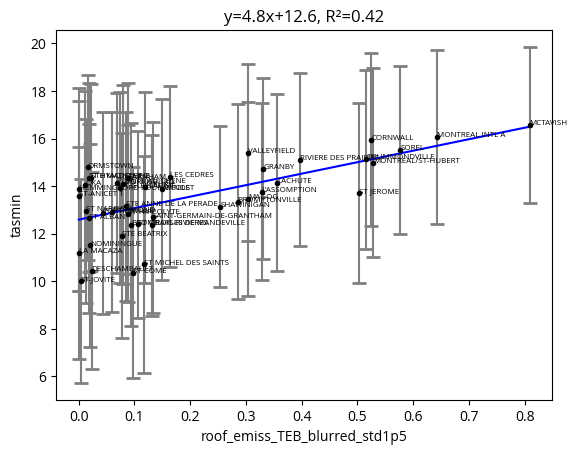

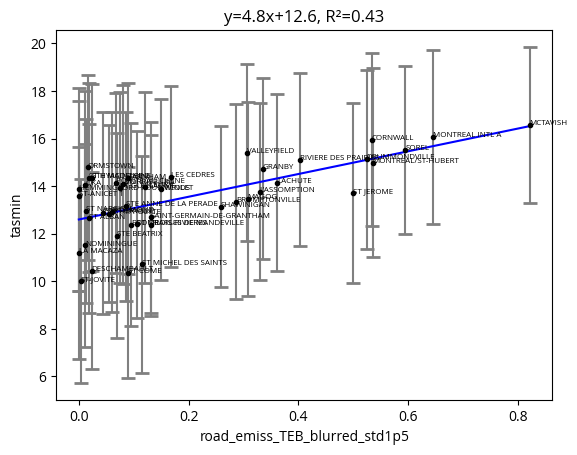

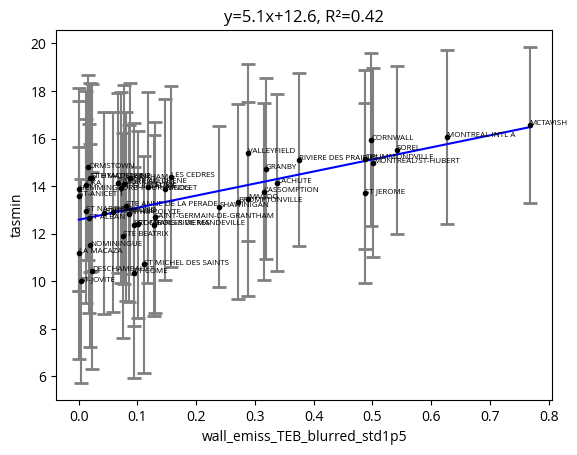

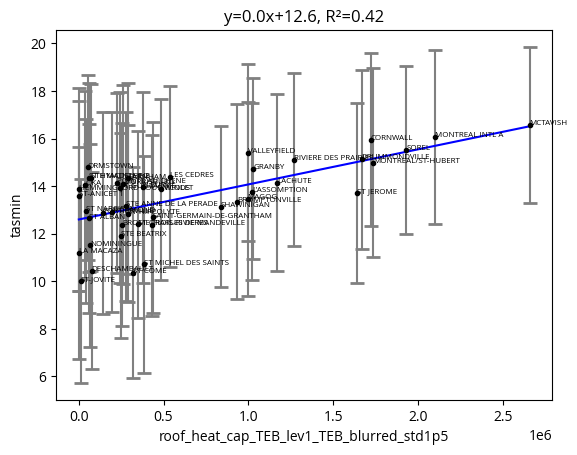

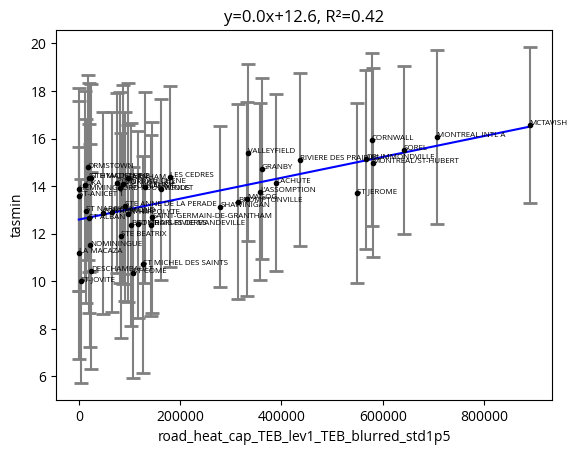

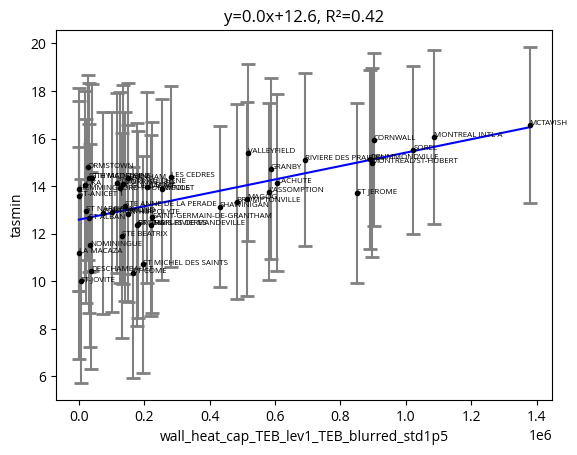

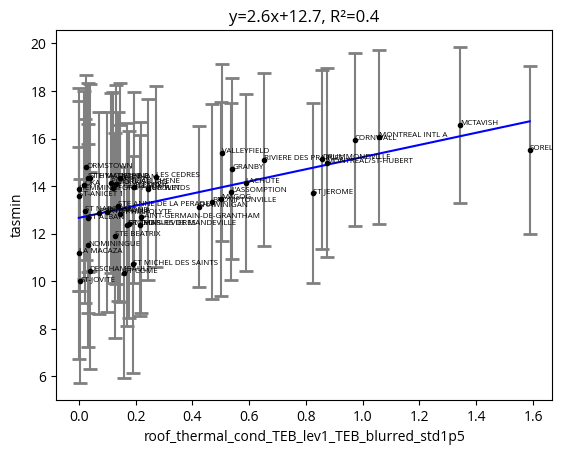

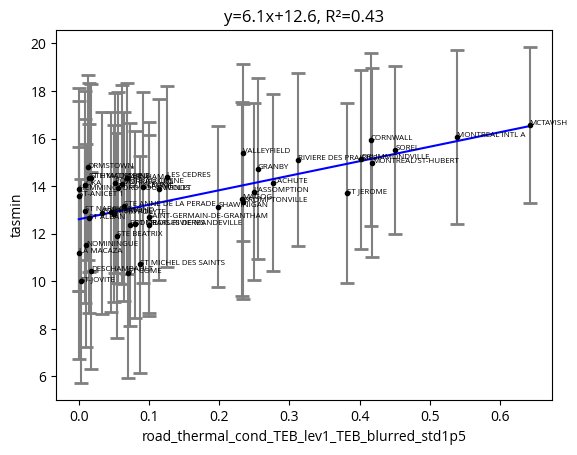

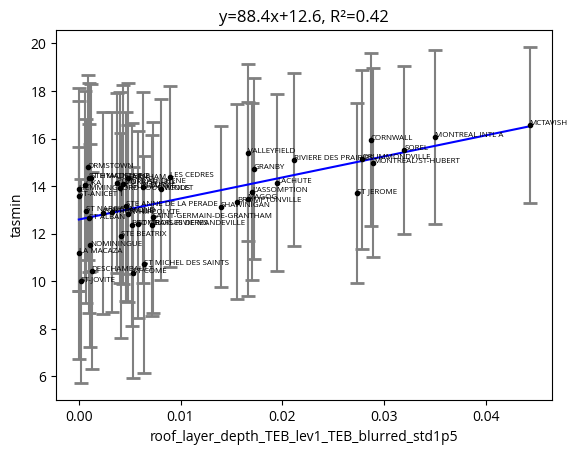

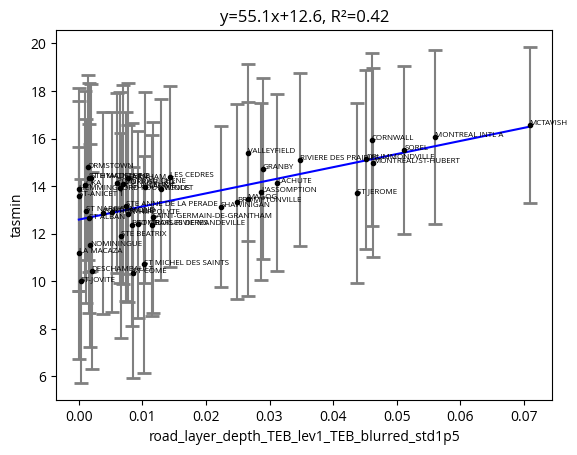

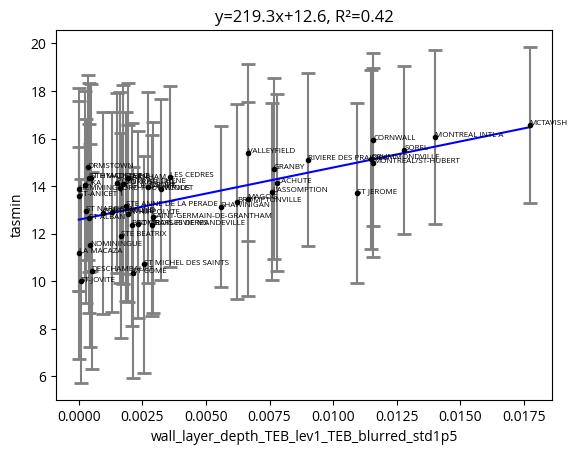

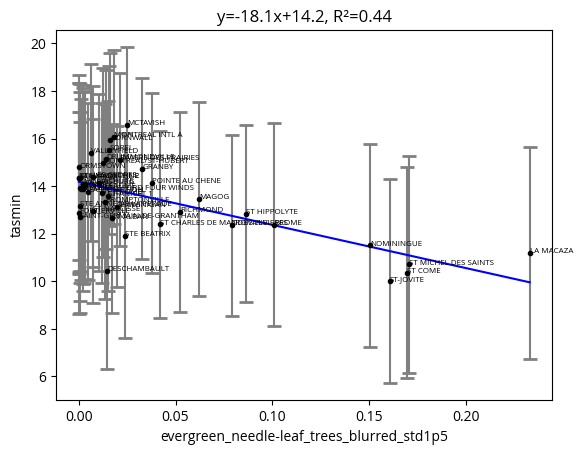

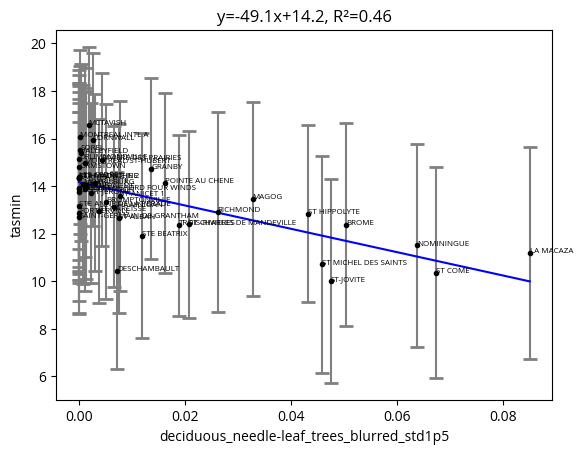

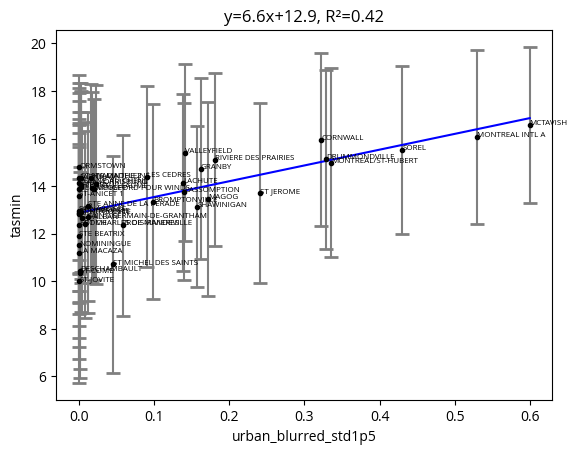

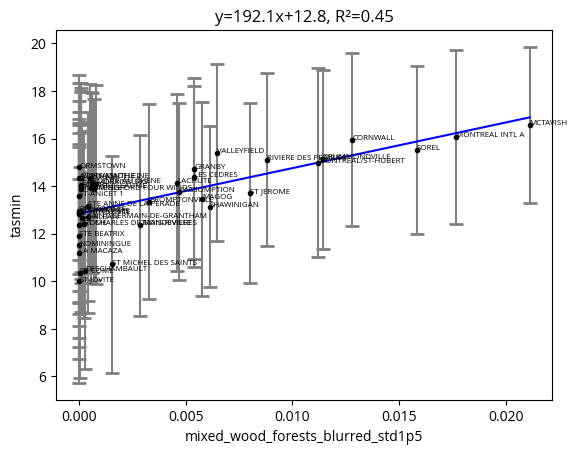

In [7]:
predictors = []
season = 'JJA'

for field in ['tasmax','tas','tasmin']:
    data = avgs[field].dropna(dim='station').sel(season=season)
    errs = stds[field].dropna(dim='station').sel(season=season)
    for coord in data.coords:
        x = data[coord].values
        y = data.values
        names = list(data['station_name'].values)
        yerr = errs.values
        
        if(np.shape(x) == np.shape(y) and (data[coord].dtype == 'float64' or data[coord].dtype == 'float32')):
            if coord not in predictors:
                predictors.append(coord)
                
            model = LinearRegression()
            X = x.reshape(-1, 1)
            model.fit(X,y)
            r_square = model.score(X,y)
            if r_square >= 0.4: # Ignore weakest linear correlations            
                
                # plt.title(season)
                plt.ylabel(field)
                plt.xlabel(coord)
                
                # plt.plot(x,y,'.',color='black',label=field)
                plt.errorbar(x, y, yerr=yerr, fmt='.',color='black', ecolor='gray', capsize=5, capthick=2)
                
                xline = np.linspace(min(x),max(x),2)
                yline = xline*model.coef_ + model.intercept_
                plt.plot(xline,yline,'b')
                plt.title(f'y={round(model.coef_[0]*10)/10}x+{round(model.intercept_*10)/10}, R²={round(r_square*100)/100}')
                for x_pos,y_pos,stn_name in zip (x,y,names):
                    plt.text(x_pos, y_pos, stn_name,size='xx-small')
            plt.show()

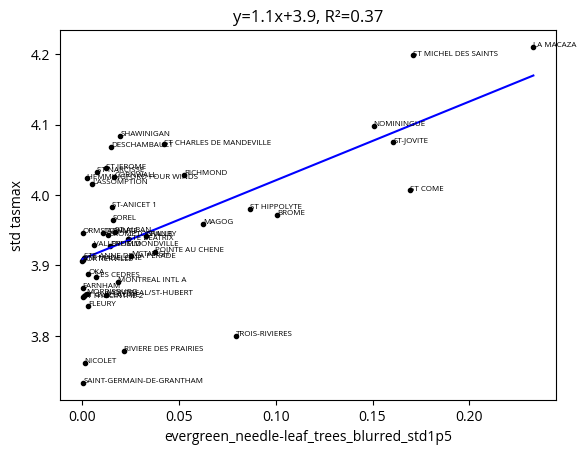

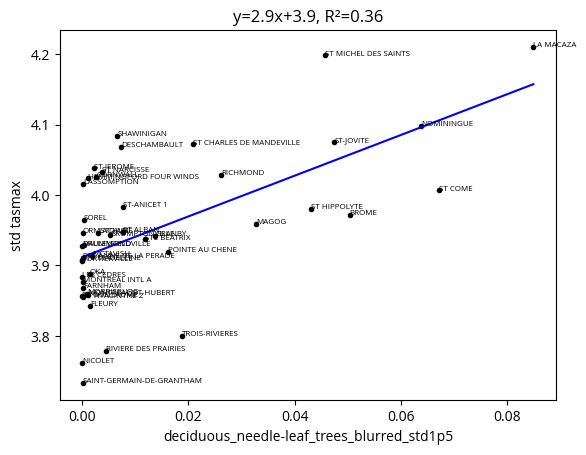

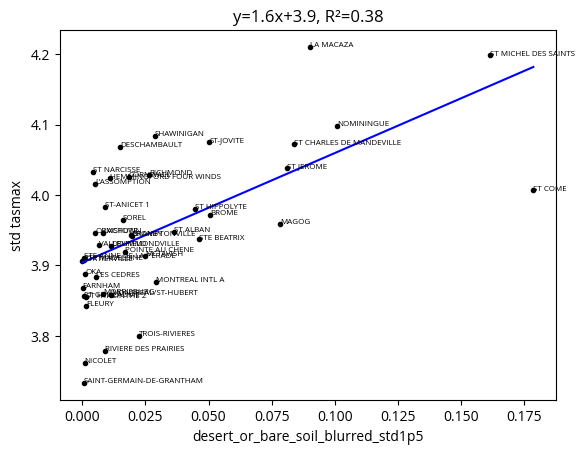

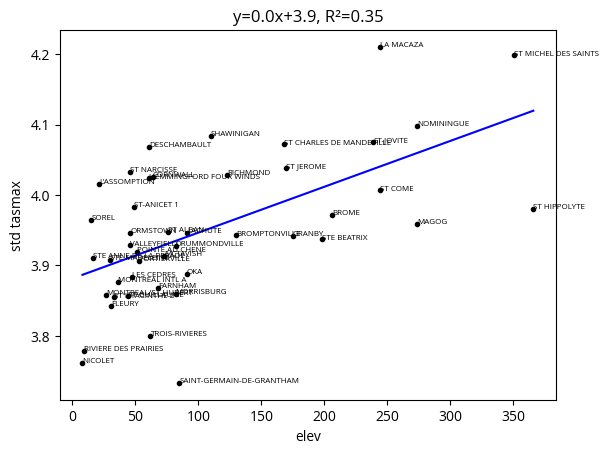

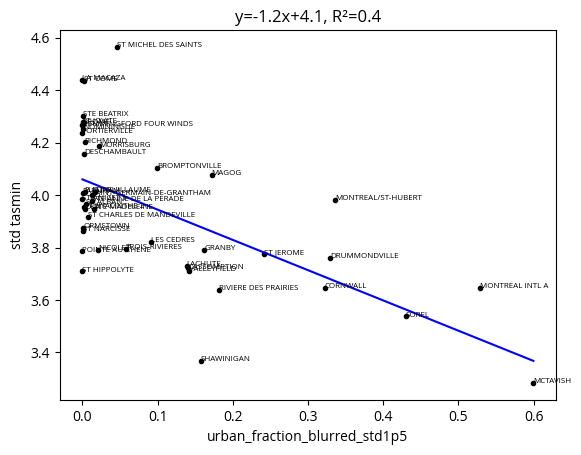

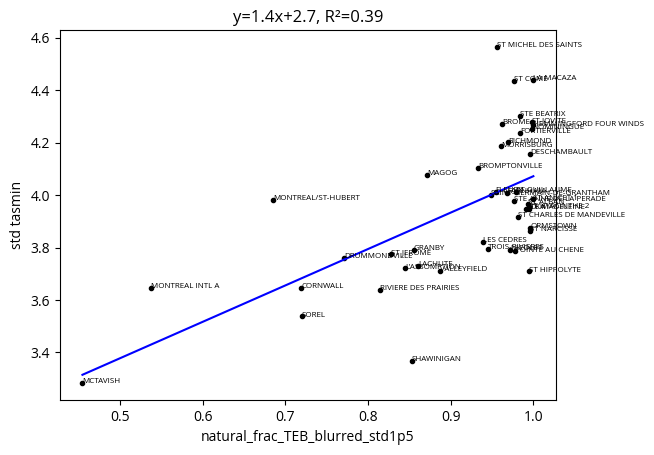

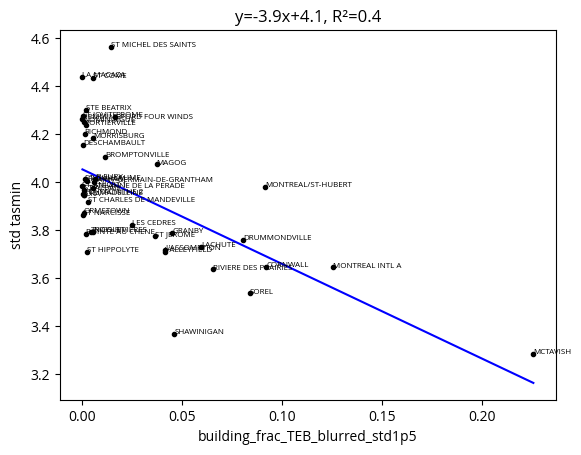

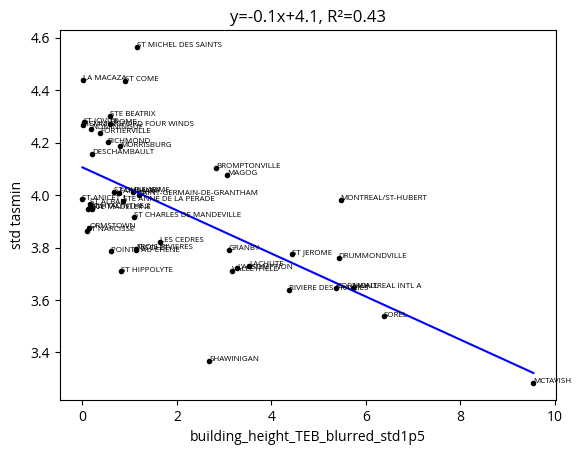

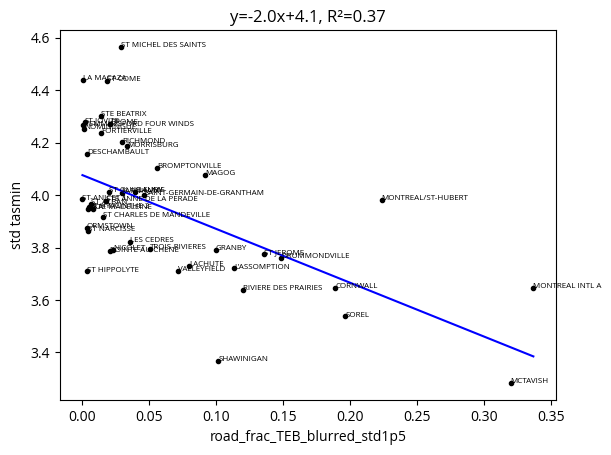

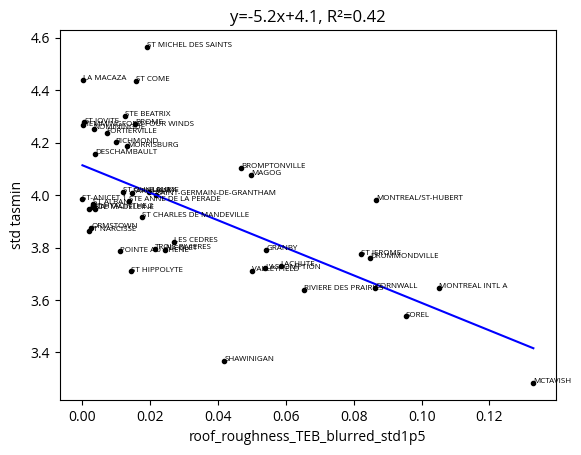

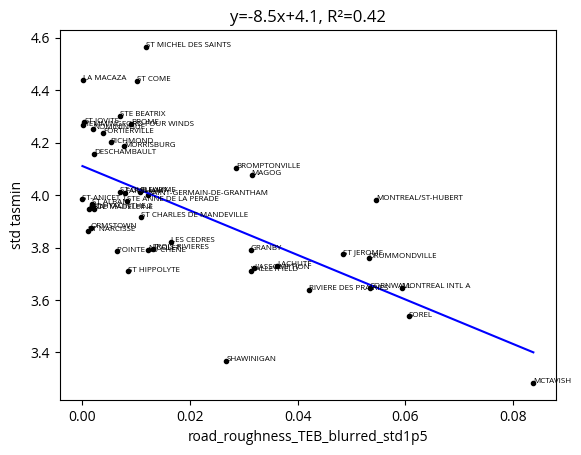

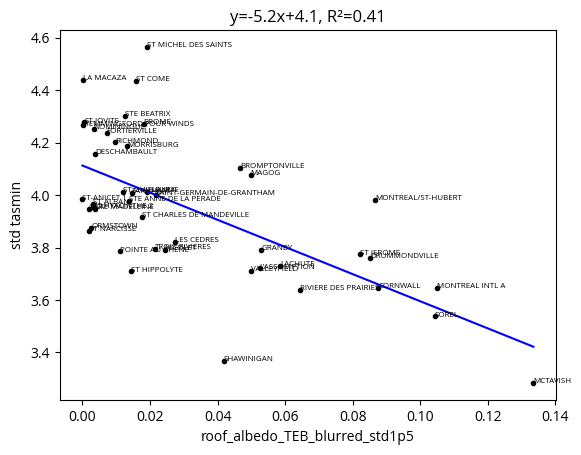

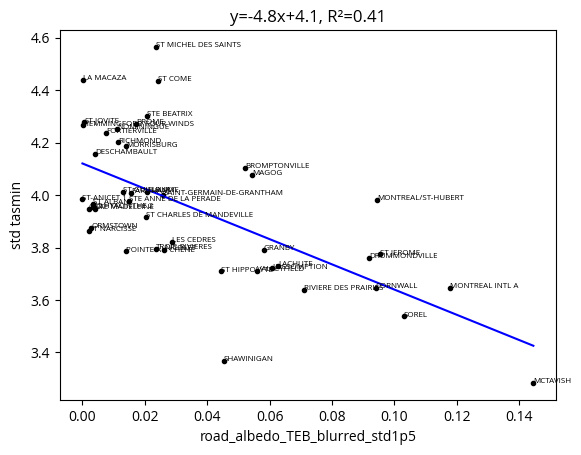

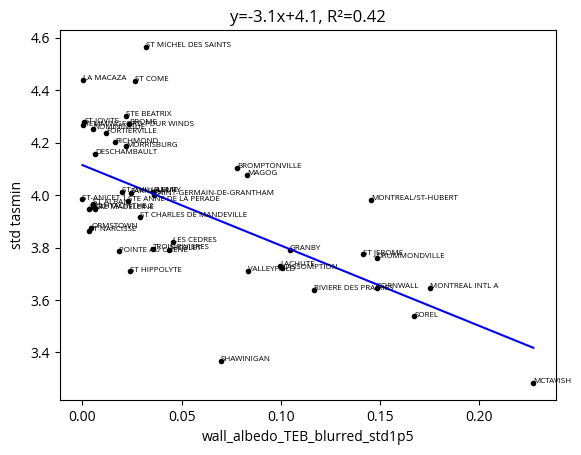

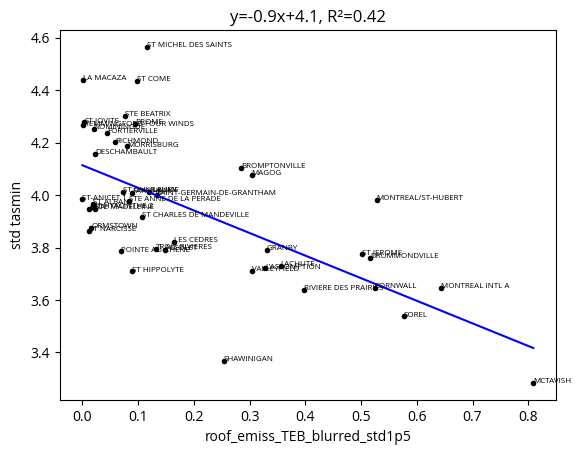

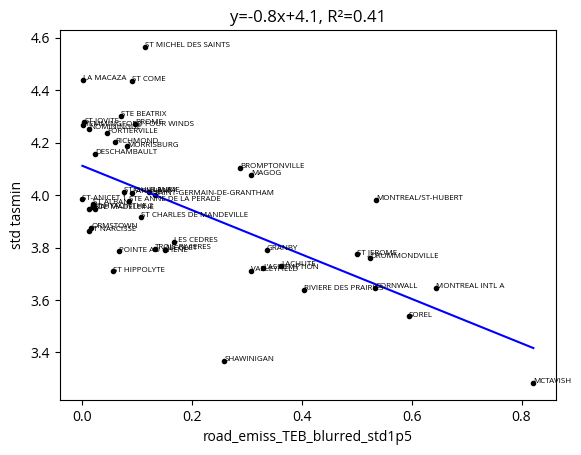

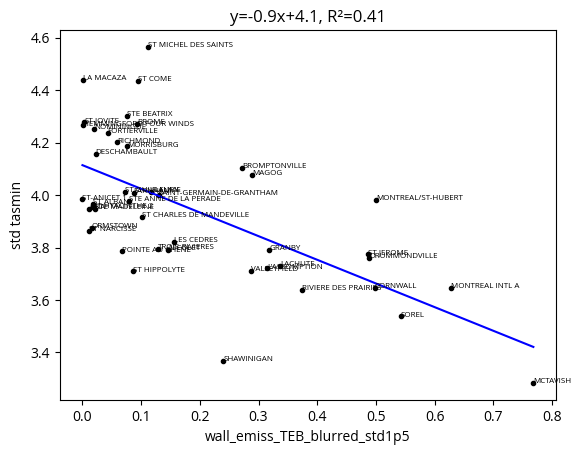

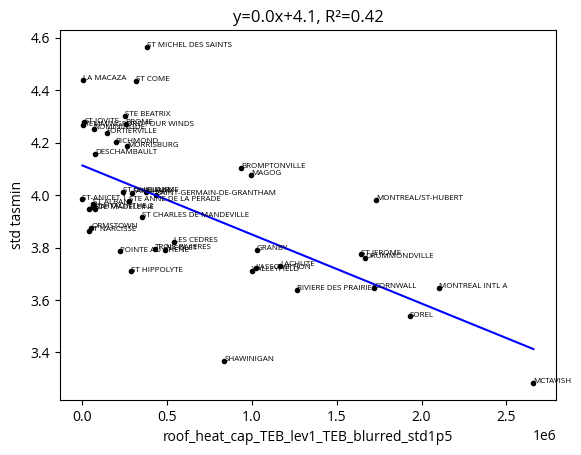

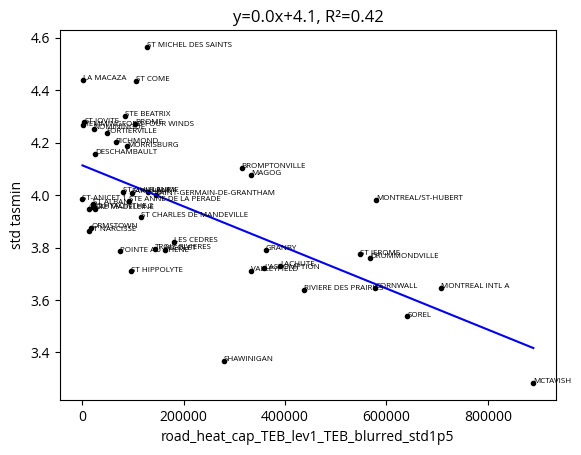

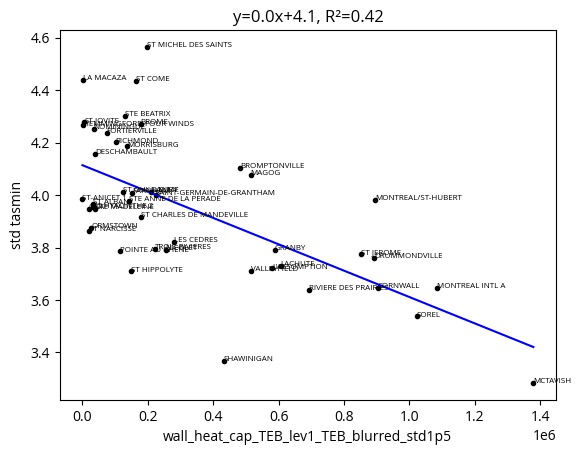

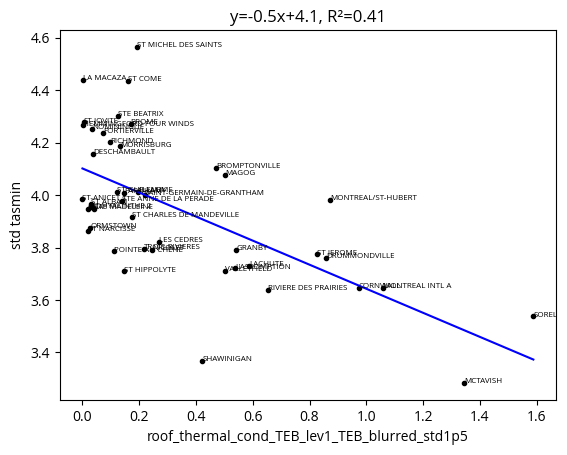

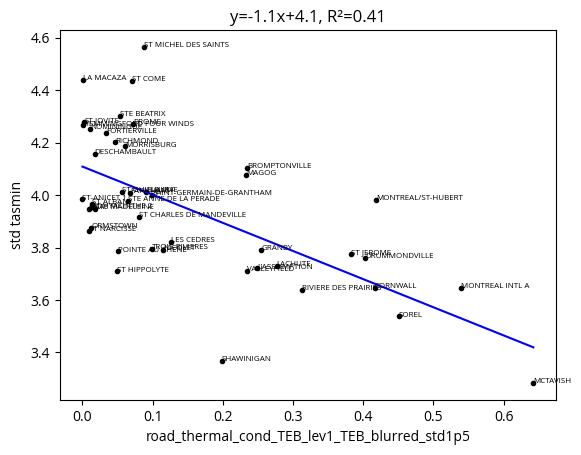

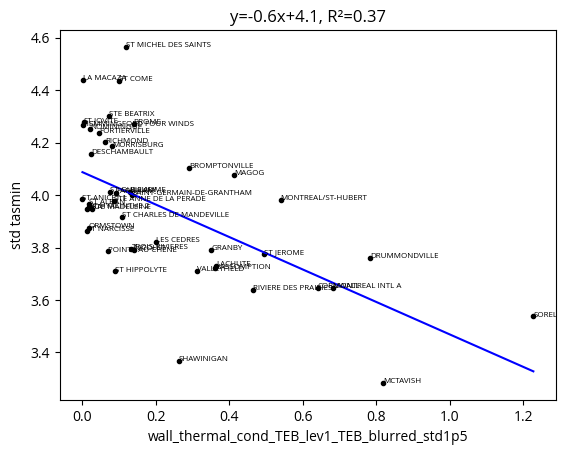

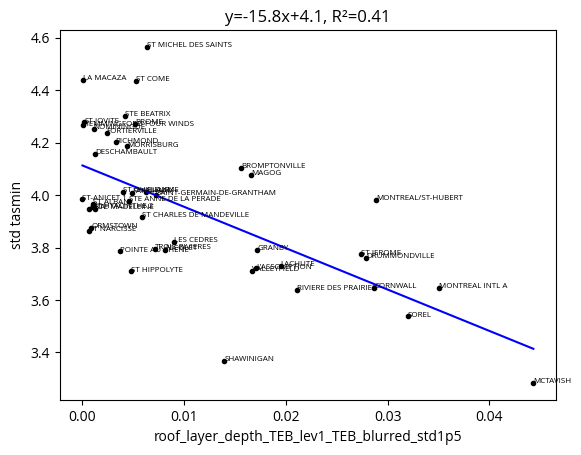

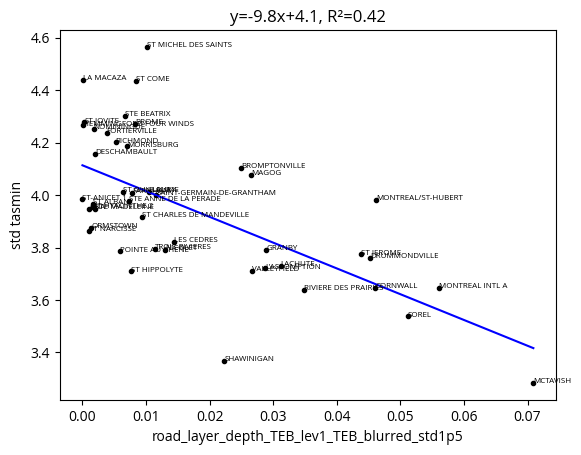

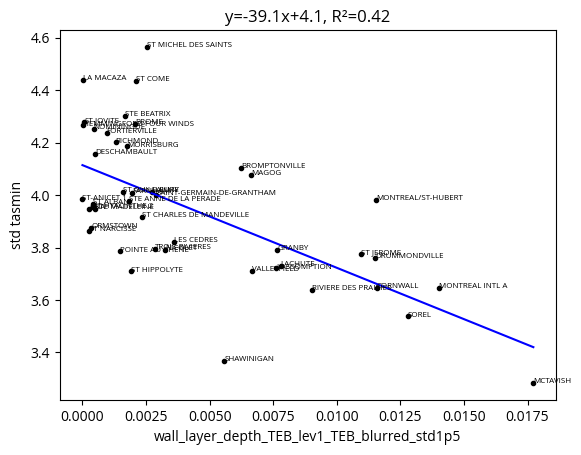

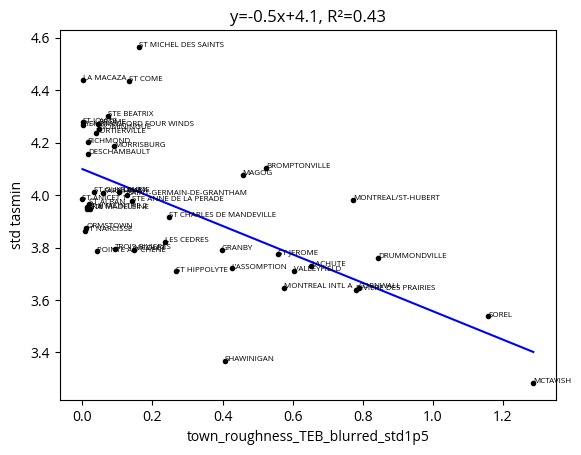

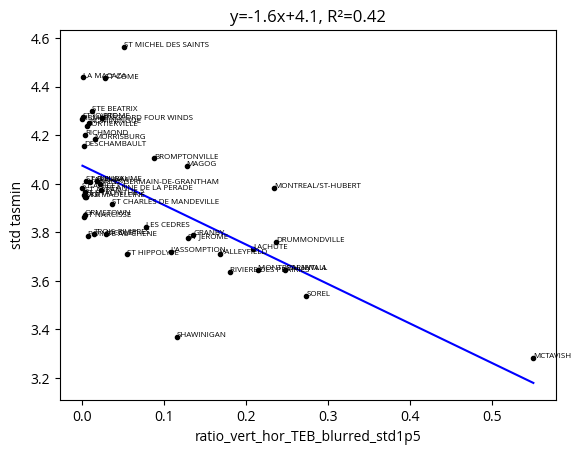

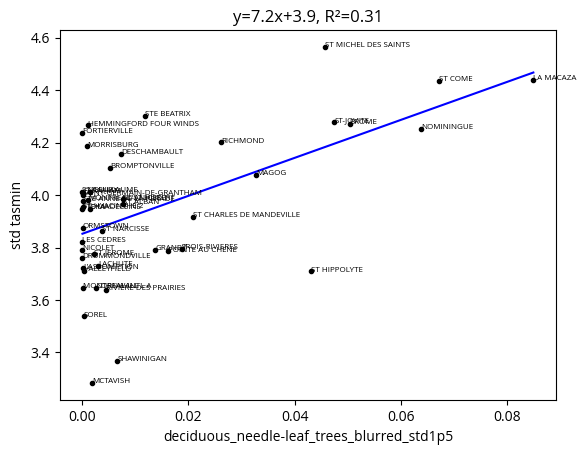

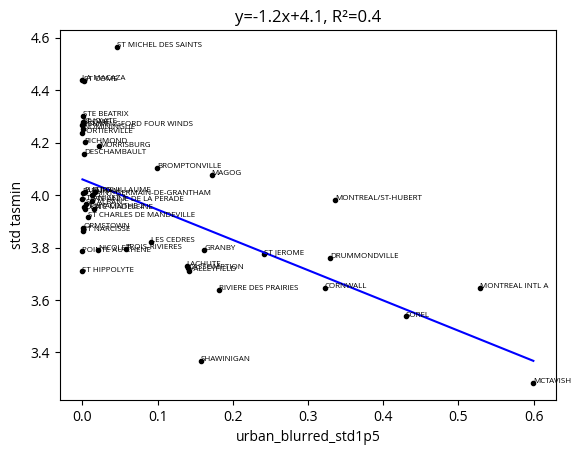

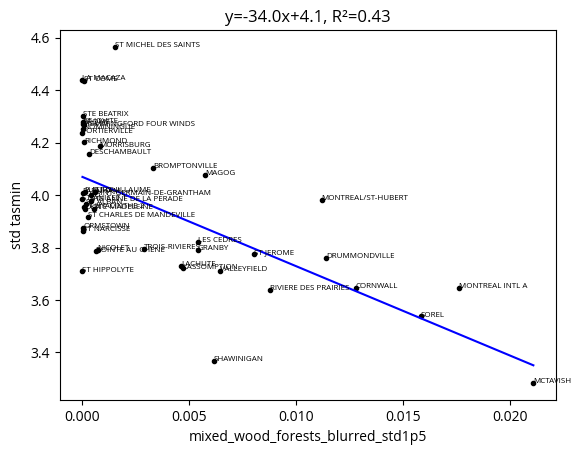

In [8]:
season = 'JJA'
for field in ['tasmax','tas','tasmin']:
    data = stds[field].dropna(dim='station').sel(season=season)
    for coord in data.coords:
        x = data[coord].values
        y = data.values
        names = list(data['station_name'].values)
        
        if(np.shape(x) == np.shape(y) and (data[coord].dtype == 'float64' or data[coord].dtype == 'float32')):

            model = LinearRegression()
            X = x.reshape(-1, 1)
            model.fit(X,y)
            r_square = model.score(X,y)
            if r_square >= 0.3: # Ignore weakest linear correlations          
                plt.ylabel(f'std {field}')
                plt.xlabel(coord)
                plt.plot(x,y,'.',color='black',label=field)
    
                xline = np.linspace(min(x),max(x),2)
                yline = xline*model.coef_ + model.intercept_
                plt.plot(xline,yline,'b')
                plt.title(f'y={round(model.coef_[0]*10)/10}x+{round(model.intercept_*10)/10}, R²={round(r_square*100)/100}')
                for x_pos,y_pos,stn_name in zip (x,y,names):
                    plt.text(x_pos, y_pos, stn_name,size='xx-small')
            plt.show()

In [18]:
da = avgs['tasmin'].sel(season='JJA').dropna(dim='station')

X = np.column_stack([da.coords[var].values for var in predictors])
y = da.values
model = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
model.fit(X, y)
ridge = model.named_steps['ridge']
print('Coefficients', ridge.coef_)

Coefficients [ 0.10031842 -0.3844099  -0.09878042  0.23780278  0.0490132   0.00208346
 -0.06924756 -0.07539843 -0.0092889  -0.03600519 -0.06261822  0.24214297
  0.14177027 -0.00625667 -0.06184973  0.00245167 -0.04765891 -0.01073861
  0.02451894 -0.12278422 -0.0716288   0.04585856 -0.05899482 -0.0104385
  0.0495587  -0.05887041 -0.05887041  0.          0.          0.10991857
  0.13018335  0.          0.          0.10031842 -0.54043113  0.11322277
  0.1375736  -0.08989264  0.          0.         -0.04614194 -0.18146189
  0.          0.14136886  0.          0.0068788   0.          0.
  0.          0.          0.          0.23780278 -0.02920768 -0.09931862
 -0.22270051  0.16475842 -0.04780382 -0.11044856]
